# Hamover Search Workflow Notebook

This notebook is the practical runner for `HamoverSearch`.
It helps you compare approaches, compare backends, and interpret diagnostics.

## Pipeline View

Theory-to-execution flow used in this notebook:

1. Define search problem (`N`, `target`).
2. Choose an approach (`farhi_gutmann`, `adiabatic`, `nonadiabatic`, `monotonic`, `custom_su2`).
3. If adiabatic, choose schedule (`roland_cerf`, `gap_power`, `constant`).
4. Build su(2) controls `(omega(t), Omega(t))` internally.
5. Evolve dynamics with Schrödinger solver.
6. Optional backend bridge (`qutip`, `sim_annealing`, `ionq`, `quera`, `classiq`) for embedded/hardware-like pathway.
7. Inspect diagnostics: integration quality, embedding error, leakage, and backend term loss.

In [1]:
from __future__ import annotations

from dataclasses import asdict
import math

import numpy as np

from hamover import HamoverSearch
from hamover.hamiltonians.scheduled import AdiabaticSearchHamiltonian
from hamover.schedules.library import RolandCerfSchedule
from hamover.solver import numerical_solve

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception as exc:
    HAS_MPL = False
    print("matplotlib unavailable:", exc)

np.set_printoptions(precision=4, suppress=True)

In [2]:
def run_case(name: str, N: int, target: int, approach: str, backend: str = "none", **setup_kwargs):
    """Run one HamoverSearch configuration and return a compact record."""
    search = HamoverSearch(N=N, target=target)
    result = search.setup(approach=approach, backend=backend, **setup_kwargs).solve()
    record = {
        "name": name,
        "N": N,
        "target": target,
        "approach": result.approach,
        "backend": result.backend,
        "probability": float(result.probability),
        "runtime": float(result.runtime),
        "found": bool(result.target_found),
        "scaling_exponent": result.scaling_exponent,
        "diagnostics": dict(result.diagnostics),
        "result": result,
    }
    return record


def print_records(records, cols=("name", "approach", "backend", "N", "probability", "runtime", "found")):
    widths = {c: max(len(c), max(len(str(r.get(c, ""))) for r in records)) for c in cols}
    header = " | ".join(c.ljust(widths[c]) for c in cols)
    sep = "-+-".join("-" * widths[c] for c in cols)
    print(header)
    print(sep)
    for r in records:
        row = []
        for c in cols:
            v = r.get(c, "")
            if isinstance(v, float):
                row.append(f"{v:.6f}".ljust(widths[c]))
            else:
                row.append(str(v).ljust(widths[c]))
        print(" | ".join(row))


def explain_diagnostics(diag: dict):
    notes = {
        "reference_probability_final": "2-level Schrodinger baseline P(w) at final time",
        "norm_deviation_max": "max deviation from unit norm during ODE integration",
        "simuq_qsystem_built": "bridge graph successfully constructed for SimuQ-style conversion",
        "embedded_probability_final": "P(w) after full embedded-space simulation",
        "validation_error_embedded": "|P_embedded - P_reference| consistency check",
        "validation_error_simuq": "SimuQ round-trip mismatch (if available)",
        "max_leakage": "max population outside encoded {w,r} subspace",
        "backend_max_leakage": "backend-side embedded leakage proxy",
        "backend_found_count": "shots decoded as target state",
        "backend_not_found_count": "shots decoded as non-target search subspace",
        "backend_leakage_count": "shots decoded outside encoded subspace",
        "backend_dropped_terms": "non-Ising Pauli terms dropped in SA mapping",
        "backend_dropped_weight": "total coefficient weight of dropped terms",
        "ionq_segments": "compiled time slices for IonQ-like analog program",
        "quera_points": "compiled control samples for QuEra-like program",
        "monotonic_scenario": "closed-form monotonic schedule scenario identifier",
        "circuit_depth": "transpiled circuit depth from Classiq synthesis",
        "cx_count": "number of CX (CNOT) gates in transpiled circuit",
        "num_qdrift": "qDRIFT random product formula repetitions (controls accuracy)",
    }
    for k, v in diag.items():
        print(f"- {k}: {v}")
        if k in notes:
            print(f"  -> {notes[k]}")

In [3]:
# Quick sanity run: adiabatic Roland-Cerf on pure solver path.
baseline = run_case(
    name="baseline_rc",
    N=1024,
    target=139,
    approach="adiabatic",
    backend="none",
    schedule="roland_cerf",
    epsilon=0.5,
    n_points=301,
    n_segments=80,
)

print_records([baseline])
print("\nDiagnostics")
explain_diagnostics(baseline["diagnostics"])

name        | approach  | backend | N    | probability        | runtime           | found
------------+-----------+---------+------+--------------------+-------------------+------
baseline_rc | adiabatic | none    | 1024 | 0.852737           | 98.578785         | True 

Diagnostics
- reference_probability_final: 0.8527373310478301
  -> 2-level Schrodinger baseline P(w) at final time
- norm_deviation_max: 8.16487988331005e-10
  -> max deviation from unit norm during ODE integration
- simuq_qsystem_built: False
  -> bridge graph successfully constructed for SimuQ-style conversion


## Approach Comparison

Compare algorithm families at similar problem size.
This is the fastest way to see whether your chosen control strategy gives enough final overlap at acceptable runtime.

name           | approach      | backend | N   | probability          | runtime            | found
---------------+---------------+---------+-----+----------------------+--------------------+------
farhi_gutmann  | farhi_gutmann | none    | 256 | 1.000000             | 25.132741          | True 
adiabatic_rc   | adiabatic     | none    | 256 | 0.845625             | 48.358721          | True 
adiabatic_gap2 | adiabatic     | none    | 256 | 0.845625             | 48.358721          | True 
nonadiabatic   | nonadiabatic  | none    | 256 | 0.006800             | 12.000000          | False
monotonic_s1   | monotonic     | none    | 256 | 0.007782             | 0.490874           | False


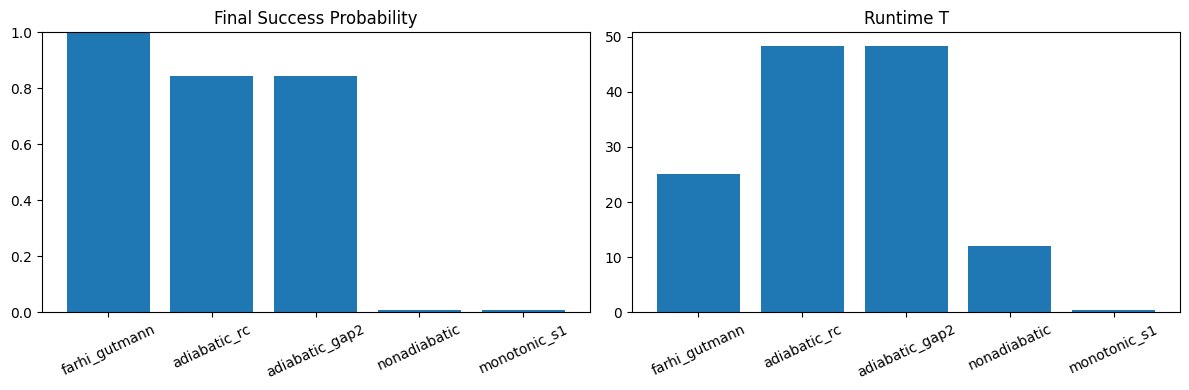

In [4]:
N = 256
target = 37

approach_runs = [
    run_case("farhi_gutmann", N, target, approach="farhi_gutmann", backend="none", E=1.0, n_points=301),
    run_case("adiabatic_rc", N, target, approach="adiabatic", backend="none", schedule="roland_cerf", epsilon=0.5, n_points=301),
    run_case("adiabatic_gap2", N, target, approach="adiabatic", backend="none", schedule="gap_power", p=2.0, epsilon=0.5, n_points=301),
    run_case("nonadiabatic", N, target, approach="nonadiabatic", backend="none", T=12.0, n_points=401),
    run_case("monotonic_s1", N, target, approach="monotonic", backend="none", scenario=1, n_points=401),
]

print_records(approach_runs)

if HAS_MPL:
    labels = [r["name"] for r in approach_runs]
    probs = [r["probability"] for r in approach_runs]
    times = [r["runtime"] for r in approach_runs]

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].bar(labels, probs)
    ax[0].set_ylim(0.0, 1.0)
    ax[0].set_title("Final Success Probability")
    ax[0].tick_params(axis="x", rotation=25)

    ax[1].bar(labels, times)
    ax[1].set_title("Runtime T")
    ax[1].tick_params(axis="x", rotation=25)

    plt.tight_layout()
    plt.show()

## Scaling Check (`N` Sweep)

This section tests whether runtime tracks approximately with `sqrt(N)` for the expected approaches.

name    | N   | probability        | runtime            | found
--------+-----+--------------------+--------------------+------
fg_N8   | 8   | 1.000000           | 4.442883           | True 
rc_N8   | 8   | 0.667643           | 7.313940           | True 
fg_N16  | 16  | 1.000000           | 6.283185           | True 
rc_N16  | 16  | 0.722345           | 10.890755          | True 
fg_N32  | 32  | 1.000000           | 8.885766           | True 
rc_N32  | 32  | 0.772447           | 16.013157          | True 
fg_N64  | 64  | 1.000000           | 12.566371          | True 
rc_N64  | 64  | 0.809167           | 23.310325          | True 
fg_N128 | 128 | 1.000000           | 17.771532          | True 
rc_N128 | 128 | 0.832591           | 33.672240          | True 
fg_N256 | 256 | 1.000000           | 25.132741          | True 
rc_N256 | 256 | 0.845625           | 48.358721          | True 


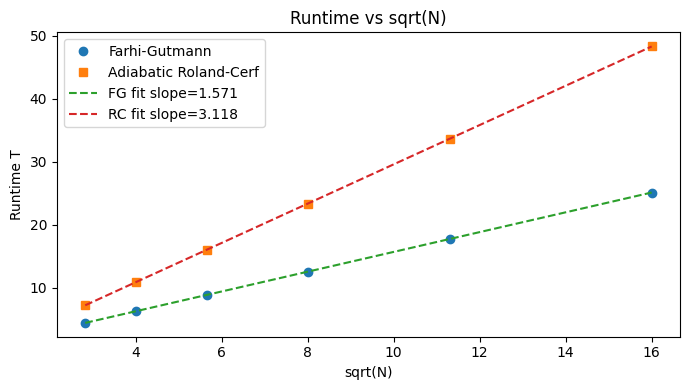

In [5]:
Ns = [8, 16, 32, 64, 128, 256]
scaling_records = []

for N in Ns:
    target = min(3, N - 1)
    scaling_records.append(
        run_case(
            name=f"fg_N{N}",
            N=N,
            target=target,
            approach="farhi_gutmann",
            backend="none",
            E=1.0,
            n_points=241,
        )
    )
    scaling_records.append(
        run_case(
            name=f"rc_N{N}",
            N=N,
            target=target,
            approach="adiabatic",
            backend="none",
            schedule="roland_cerf",
            epsilon=0.5,
            n_points=241,
        )
    )

print_records(scaling_records, cols=("name", "N", "probability", "runtime", "found"))

if HAS_MPL:
    sqrtN = np.sqrt(np.array(Ns, dtype=float))
    fg = np.array([r["runtime"] for r in scaling_records if r["name"].startswith("fg_")])
    rc = np.array([r["runtime"] for r in scaling_records if r["name"].startswith("rc_")])

    c_fg = np.polyfit(sqrtN, fg, deg=1)
    c_rc = np.polyfit(sqrtN, rc, deg=1)

    xfit = np.linspace(sqrtN.min(), sqrtN.max(), 100)
    yfg = c_fg[0] * xfit + c_fg[1]
    yrc = c_rc[0] * xfit + c_rc[1]

    plt.figure(figsize=(7, 4))
    plt.plot(sqrtN, fg, "o", label="Farhi-Gutmann")
    plt.plot(sqrtN, rc, "s", label="Adiabatic Roland-Cerf")
    plt.plot(xfit, yfg, "--", label=f"FG fit slope={c_fg[0]:.3f}")
    plt.plot(xfit, yrc, "--", label=f"RC fit slope={c_rc[0]:.3f}")
    plt.xlabel("sqrt(N)")
    plt.ylabel("Runtime T")
    plt.title("Runtime vs sqrt(N)")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Backend Pathway Comparison

Same high-level search setup, different backend path:

- `none`: pure reduced 2-level solver.
- `qutip`: embedded-state local validation path.
- `sim_annealing`: Ising projection + simulated annealing readout proxy.
- `classiq`: gate-based qDRIFT circuit synthesis + Classiq simulator execution.

In [6]:
backend_runs = [
    run_case(
        "backend_none",
        N=32,
        target=7,
        approach="adiabatic",
        backend="none",
        schedule="roland_cerf",
        epsilon=0.5,
        n_points=241,
        n_segments=60,
    ),
    run_case(
        "backend_qutip",
        N=32,
        target=7,
        approach="adiabatic",
        backend="qutip",
        schedule="roland_cerf",
        epsilon=0.5,
        n_points=241,
        n_segments=60,
    ),
    run_case(
        "backend_sim_annealing",
        N=32,
        target=7,
        approach="adiabatic",
        backend="sim_annealing",
        schedule="roland_cerf",
        epsilon=0.5,
        n_points=241,
        n_segments=60,
        shots=500,
        rng_seed=1,
    ),
]

print_records(backend_runs)

for rec in backend_runs:
    print(f"\n[{rec['name']}] diagnostics")
    explain_diagnostics(rec["diagnostics"])

name                  | approach  | backend       | N  | probability        | runtime            | found
----------------------+-----------+---------------+----+--------------------+--------------------+------
backend_none          | adiabatic | none          | 32 | 0.772447           | 16.013157          | True 
backend_qutip         | adiabatic | qutip         | 32 | 0.772447           | 16.013157          | True 
backend_sim_annealing | adiabatic | sim_annealing | 32 | 1.000000           | 16.013157          | True 

[backend_none] diagnostics
- reference_probability_final: 0.7724472024383234
  -> 2-level Schrodinger baseline P(w) at final time
- norm_deviation_max: 1.2227086010341282e-10
  -> max deviation from unit norm during ODE integration
- simuq_qsystem_built: False
  -> bridge graph successfully constructed for SimuQ-style conversion

[backend_qutip] diagnostics
- reference_probability_final: 0.7724472024383234
  -> 2-level Schrodinger baseline P(w) at final time
- norm_devi

c:\Users\azain\hamover\hamover\search.py:112: RuntimeWarning: Non-Ising Pauli terms were dropped during D-Wave mapping (count=512, total_weight=5.218e+00)
  sa = run_simulated_annealing(


## Diagnostics Reading Guide

When diagnostics look bad:

- Large `norm_deviation_max`: increase `n_points` or tighten ODE settings in solver code.
- Large `validation_error_embedded`: increase embedding penalty, increase segment resolution, or check mapping.
- Large `max_leakage`/`backend_max_leakage`: your encoded subspace is not isolated strongly enough.
- Nonzero `backend_dropped_terms`: SA mapping discarded terms; treat SA probability as an approximation.
- `backend_leakage_count` high: decoded bitstrings fall outside intended `w/r` subspace.

## Classiq qDRIFT Backend: Gate-Based Hamiltonian Simulation

The Classiq backend takes a fundamentally different route from the analog backends (D-Wave, IonQ, QuEra).
Instead of mapping controls to hardware-native pulse sequences, it compiles the *full* embedded Hamiltonian
into a gate-based quantum circuit using **qDRIFT** (randomized product formula).

### Route through the code

```
su(2) H(t)                          # 2x2 search Hamiltonian
  -> embedding.embedded_hamiltonian()  # lift to 2^n Hilbert space with penalty
  -> embedding.pauli_coefficients_at() # decompose into Pauli basis: H = sum c_k P_k
  -> _hamover_pauli_to_classiq()       # convert to Classiq SparsePauliOp
  -> qdrift(pauli_op, T, num_qdrift)   # synthesize e^{-iHT} as randomized gate circuit
  -> execute() + embedding.decode()    # measure bitstrings, classify as w/r/leakage
```

### Why this is true Hamiltonian simulation

1. **Same Hamiltonian.** The Pauli decomposition of `H_embed(t)` is *identical* to the operator
   that QuTiP integrates via `sesolve`. No terms are dropped.

2. **qDRIFT approximates `e^{-iHt}` faithfully.** Given `H = sum c_k P_k`, qDRIFT randomly
   samples terms proportional to `|c_k|` and applies short unitary rotations. Error scales
   as `O(t^2 / num_qdrift)` — controllable by increasing `num_qdrift`.

3. **No term-dropping.** This is the critical advantage over analog backends:
   - D-Wave: drops every non-Z/ZZ Pauli term (X, Y, XY, XZ, etc.)
   - IonQ: keeps only XX + Z terms
   - **Classiq qDRIFT: preserves all Pauli terms**

4. **Exact initial state.** `prepare_amplitudes()` synthesizes a circuit producing
   `x|w> + sqrt(1-x^2)|r>` — the same starting state as QuTiP.

### Accuracy controls

| Parameter | Effect | Tradeoff |
|-----------|--------|----------|
| `num_qdrift` | More random samples per time step | Deeper circuit, better accuracy |
| `n_segments` | Finer time discretization (for time-dependent H) | More qDRIFT blocks, handles fast-varying fields |
| `shots` | Measurement repetitions | Lower statistical noise |

For time-independent Hamiltonians (e.g. Farhi-Gutmann), a single qDRIFT block covers the
full evolution — no `n_segments` discretization needed.

In [10]:
# --- Classiq qDRIFT: Farhi-Gutmann on N=4 (time-independent H) ---
# This is the simplest case: static Hamiltonian, single qDRIFT block.


classiq_fg = run_case(
    "classiq_fg_N4",
    N=10,
    target=3,
    approach="farhi_gutmann",
    backend="classiq",
    num_qdrift=20,
    shots=500,
    n_segments=50,
)

print("=== Farhi-Gutmann N=4 via Classiq qDRIFT ===")
print_records([classiq_fg])
print("\nDiagnostics")
explain_diagnostics(classiq_fg["diagnostics"])

# Compare: reference (exact ODE) vs classiq (gate-based qDRIFT)
p_ref = classiq_fg["diagnostics"]["reference_probability_final"]
p_cq = classiq_fg["probability"]
print(f"\nReference P(T) from 2-level ODE: {p_ref:.6f}")
print(f"Classiq qDRIFT measured P(w):    {p_cq:.6f}")
print(f"Shots decoded as target:         {classiq_fg['diagnostics']['backend_found_count']}")
print(f"Shots decoded as non-target:     {classiq_fg['diagnostics']['backend_not_found_count']}")
print(f"Shots decoded as leakage:        {classiq_fg['diagnostics']['backend_leakage_count']}")

=== Farhi-Gutmann N=4 via Classiq qDRIFT ===
name          | approach      | backend | N  | probability | runtime           | found
--------------+---------------+---------+----+-------------+-------------------+------
classiq_fg_N4 | farhi_gutmann | classiq | 10 | 1.000000    | 4.967294          | False

Diagnostics
- reference_probability_final: 0.9999999999057072
  -> 2-level Schrodinger baseline P(w) at final time
- norm_deviation_max: 9.429279579364902e-11
  -> max deviation from unit norm during ODE integration
- simuq_qsystem_built: False
  -> bridge graph successfully constructed for SimuQ-style conversion
- embedded_probability_final: 0.9999999991298809
  -> P(w) after full embedded-space simulation
- validation_error_embedded: 8.244145366376188e-10
  -> |P_embedded - P_reference| consistency check
- validation_error_simuq: None
  -> SimuQ round-trip mismatch (if available)
- max_leakage: 8.701190878901871e-10
  -> max population outside encoded {w,r} subspace
- backend_found_

In [ ]:
# --- Backend comparison: classiq vs sim_annealing vs qutip on same problem ---
# Shows that qDRIFT preserves all Pauli terms while SA drops non-Ising terms.

N_cmp, target_cmp = 8, 3

classiq_vs_runs = [
    run_case(
        "none",
        N_cmp, target_cmp,
        approach="farhi_gutmann",
        backend="none",
    ),
    run_case(
        "qutip",
        N_cmp, target_cmp,
        approach="farhi_gutmann",
        backend="qutip",
        n_segments=50,
    ),
    run_case(
        "sim_annealing",
        N_cmp, target_cmp,
        approach="farhi_gutmann",
        backend="sim_annealing",
        shots=500,
        rng_seed=42,
        n_segments=50,
    ),
    run_case(
        "classiq",
        N_cmp, target_cmp,
        approach="farhi_gutmann",
        backend="classiq",
        num_qdrift=30,
        shots=500,
        n_segments=50,
    ),
]

print(f"=== Backend Comparison: Farhi-Gutmann N={N_cmp} ===")
print_records(classiq_vs_runs)

# Highlight the term-dropping difference
sa_diag = classiq_vs_runs[2]["diagnostics"]
print(f"\nSim-annealing dropped {sa_diag.get('backend_dropped_terms', 0)} Pauli terms "
      f"(weight {sa_diag.get('backend_dropped_weight', 0):.3f})")
print("Classiq qDRIFT: 0 terms dropped (all Pauli terms preserved)")

In [12]:
# --- Classiq with time-dependent H: adiabatic Roland-Cerf ---
# This triggers the piecewise-constant discretization path (n_segments qDRIFT blocks).

classiq_adiabatic = run_case(
    "classiq_rc_N4",
    N=10,
    target=1,
    approach="adiabatic",
    backend="classiq",
    schedule="roland_cerf",
    epsilon=0.5,
    num_qdrift=15,
    n_segments=30,
    shots=500,
)

print("=== Adiabatic Roland-Cerf N=4 via Classiq qDRIFT (time-dependent) ===")
print_records([classiq_adiabatic])
print("\nDiagnostics")
explain_diagnostics(classiq_adiabatic["diagnostics"])

=== Adiabatic Roland-Cerf N=4 via Classiq qDRIFT (time-dependent) ===
name          | approach  | backend | N  | probability | runtime           | found
--------------+-----------+---------+----+-------------+-------------------+------
classiq_rc_N4 | adiabatic | classiq | 10 | 1.000000    | 8.326972          | False

Diagnostics
- reference_probability_final: 0.684552164563807
  -> 2-level Schrodinger baseline P(w) at final time
- norm_deviation_max: 1.1881440276084732e-10
  -> max deviation from unit norm during ODE integration
- simuq_qsystem_built: False
  -> bridge graph successfully constructed for SimuQ-style conversion
- embedded_probability_final: 0.6845521646239862
  -> P(w) after full embedded-space simulation
- validation_error_embedded: 5.536116010063097e-11
  -> |P_embedded - P_reference| consistency check
- validation_error_simuq: None
  -> SimuQ round-trip mismatch (if available)
- max_leakage: 7.596850926105958e-09
  -> max population outside encoded {w,r} subspace
- b

## Propagator vs Schrödinger Solver

- `schrodinger.evolve`: directly integrates state ODE (`dpsi/dt = -iHpsi`).
- `propagator.evolve_with_propagator`: builds explicit unitary history by midpoint exponentials.

Use propagator when you need explicit `U(t)` and unitarity diagnostics.
Use Schrödinger path for faster direct state evolution.

Schrodinger P(T): 0.80916669
Propagator P(T):  0.80916583
|delta|:          8.678e-07
Norm deviation max (Schrodinger): 1.916e-10
Unitarity error max (Propagator): 1.787e-13


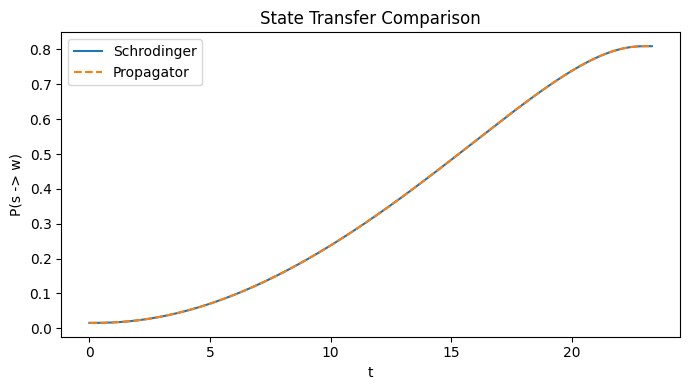

In [7]:
N = 64
x = 1.0 / math.sqrt(N)
schedule = RolandCerfSchedule(x=x, epsilon=0.5)
ham = AdiabaticSearchHamiltonian(schedule=schedule, x=x)

bundle = numerical_solve(
    hamiltonian=ham,
    x=x,
    T=schedule.T,
    n_points=301,
    with_propagator=True,
    propagator_steps=1500,
)

sch = bundle.schrodinger
prop = bundle.propagator

p_sch = float(sch.probability_sw[-1])
p_prop = float(prop.probability_sw[-1])
delta = abs(p_sch - p_prop)

print(f"Schrodinger P(T): {p_sch:.8f}")
print(f"Propagator P(T):  {p_prop:.8f}")
print(f"|delta|:          {delta:.3e}")
print(f"Norm deviation max (Schrodinger): {sch.norm_deviation_max:.3e}")
print(f"Unitarity error max (Propagator): {prop.unitarity_error_max:.3e}")

if HAS_MPL:
    plt.figure(figsize=(7, 4))
    plt.plot(sch.t, sch.probability_sw, label="Schrodinger")
    plt.plot(prop.t, prop.probability_sw, "--", label="Propagator")
    plt.xlabel("t")
    plt.ylabel("P(s -> w)")
    plt.title("State Transfer Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Next Experiments

1. Increase `N` and fit runtime against `sqrt(N)` for each approach.
2. Sweep schedule parameters (`epsilon`, `p`) and compare success/runtime frontier.
3. Sweep `penalty_strength` for backend paths and monitor leakage vs performance.
4. For SA pathway, increase `shots` and compare variance in decoded success probability.